<a href="https://colab.research.google.com/github/zaebalreal/uni-projects/blob/main/project_esport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import logging
from urllib.parse import urljoin
from IPython.display import display

# ==================================
# CHANGE HERE: site settings
# ==================================
BASE_URL = "https://sosalkino.sbs/new/"
PAGE_URL_TEMPLATE = "https://sosalkino.sbs/new/page{}"   # or ?page={}
PAGES_TO_SCRAPE = 5

HEADERS = {
    "User-Agent": "SDS106-StudentProject/1.0"
}

REQUEST_DELAY = 1
TIMEOUT = 10

# ==================================
# logging
# ==================================
logging.basicConfig(
    filename="video_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# ==================================
# helper functions
# ==================================
def get_text_or_none(element):
    if element:
        return element.get_text(strip=True)
    return None

def get_attr_or_none(element, attr):
    if element and element.has_attr(attr):
        return element[attr]
    return None

def make_absolute(base_url, link):
    if not link:
        return None
    return urljoin(base_url, link)

# ==================================
# scraping
# ==================================
all_videos = []

for page in range(1, PAGES_TO_SCRAPE + 1):
    url = PAGE_URL_TEMPLATE.format(page)
    print(f"Scraping page {page}: {url}")

    try:
        response = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        cards = []
        for a in soup.find_all("a", href=True):
            href = a["href"]
            if "/video/" in href:   # CHANGE HERE
                cards.append(a)

        print("Found cards:", len(cards))

        for card in cards:
            href = card.get("href")
            video_url = urljoin(BASE_URL, href) if href else None

            img_tag = card.find("screen")
            thumbnail = img_tag.get("src") if img_tag else None

            duration_tag = card.find("div", class_="videoduration")   # CHANGE HERE
            duration = duration_tag.get_text(strip=True) if duration_tag else None

            title = card.get("title") or card.get_text(strip=True)

            parent = card.parent
            views_tag = card.find("span", class_="videoviews")
            views = views_tag.get_text(strip=True) if views_tag else None

            all_videos.append({
                "title": title,
                "video_url": video_url,
                "thumbnail_url": thumbnail,
                "duration_raw": duration,
                "views_raw": views,
                "page": page
            })

        time.sleep(REQUEST_DELAY)

    except requests.exceptions.RequestException as e:
        print(f"Request error on page {page}: {e}")

df = pd.DataFrame(all_videos)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

display(df.head(20))
print("Total rows:", len(df))

Scraping page 1: https://sosalkino.sbs/new/page1
Found cards: 20
Scraping page 2: https://sosalkino.sbs/new/page2
Found cards: 20
Scraping page 3: https://sosalkino.sbs/new/page3
Found cards: 20
Scraping page 4: https://sosalkino.sbs/new/page4
Found cards: 20
Scraping page 5: https://sosalkino.sbs/new/page5
Found cards: 20


,title,video_url,thumbnail_url,duration_raw,views_raw,page
0,Кудрявая брюнетка скачет на члене и классно трясет голой задницей2395012:24,https://sosalkino.sbs/video/kudryavaya_bryunetka_skachet_na_chlene_i_klassno_tryaset_goloy_zadnitsey,None,12:24,23950,1
1,Татуированный парень потрепал членом манящее очко подруги в черных чулках1305910:15,https://sosalkino.sbs/video/tatuirovannyiy_paren_potrepal_chlenom_manyaschee_ochko_podrugi_v_chernyih_chulkah,None,10:15,13059,1
2,Белоснежная девка лечит депрессию сексом с чернокожим мачо564712:27,https://sosalkino.sbs/video/belosnejnaya_devka_lechit_depressiyu_seksom_s_chernokojim_macho,None,12:27,5647,1
3,Кокетка с плоским животиком руками задрочила хрен любимого до семяизвержения1032912:40,https://sosalkino.sbs/video/koketka_s_ploskim_jivotikom_rukami_zadrochila_hren_lyubimogo_do_semyaizverjeniya,None,12:40,10329,1
4,Голой служанке молодой хозяин как следует отодрал сладкую дырочку между красивых ножек941612:22,https://sosalkino.sbs/video/goloy_slujanke_molodoy_hozyain_kak_sleduet_otodral_sladkuyu_dyirochku_mejdu_krasivyih_nojek,None,12:22,9416,1
5,Девка с волосатой писей на улице ловит кайф от языка и члена любовника843210:08,https://sosalkino.sbs/video/devka_s_volosatoy_pisey_na_ulitse_lovit_kayf_ot_yazyika_i_chlena_lyubovnika,None,10:08,8432,1
6,Лысый парень на кухне мнет сиськи и попку голой любовнице952307:59,https://sosalkino.sbs/video/lyisyiy_paren_na_kuhne_mnet_siski_i_popku_goloy_lyubovnitse,None,07:59,9523,1
7,Анальному отверстию элитной давалки пришлось не сладко в сексе с новым парнем793812:20,https://sosalkino.sbs/video/analnomu_otverstiyu_elitnoy_davalki_prishlos_ne_sladko_v_sekse_s_novyim_parnem,None,12:20,7938,1
8,Хозяйка магазина женского белья трахается с начальником СБ1269212:56,https://sosalkino.sbs/video/hozyayka_magazina_jenskogo_belya_trahaetsya_s_nachalnikom_sb,None,12:56,12692,1
9,В 69 позе две голенькие лесбиянки лижут друг другу сочные половые дырочки674012:40,https://sosalkino.sbs/video/v_69_poze_dve_golenkie_lesbiyanki_lijut_drug_drugu_sochnyie_polovyie_dyirochki,None,12:40,6740,1


Total rows: 100


In [ ]:
df.to_csv('video_catalog_raw.csv', index=False)

             views  duration_seconds  duration_minutes  title_length  views_per_minute
count    100.00000        100.000000        100.000000    100.000000        100.000000
mean    7338.44000        673.670000         11.227833     75.770000        696.642278
std     4562.92455        229.167446          3.819457      8.568034        451.432701
min     1820.00000        375.000000          6.250000     59.000000        140.216749
25%     4623.50000        492.000000          8.200000     70.000000        412.789659
50%     5707.00000        655.500000         10.925000     76.000000        534.583295
75%     8375.00000        747.250000         12.454167     81.250000        819.054276
max    23950.00000       2030.000000         33.833333     95.000000       2398.780488


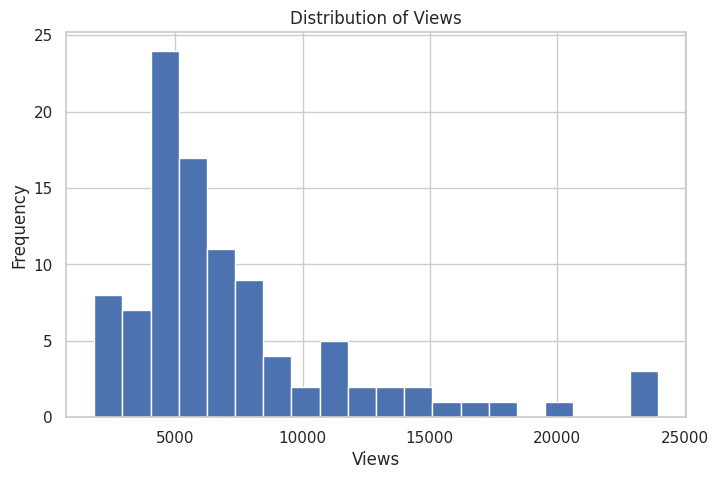

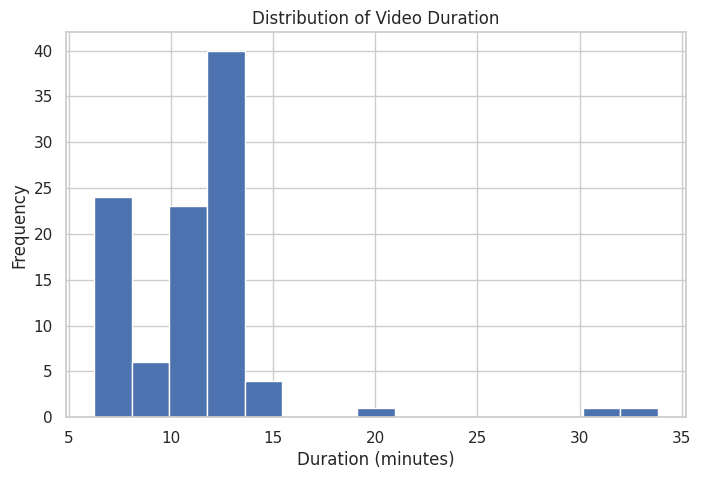

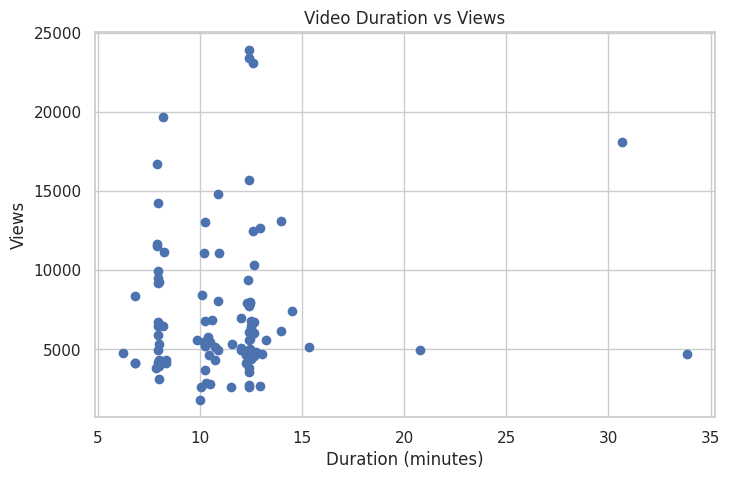

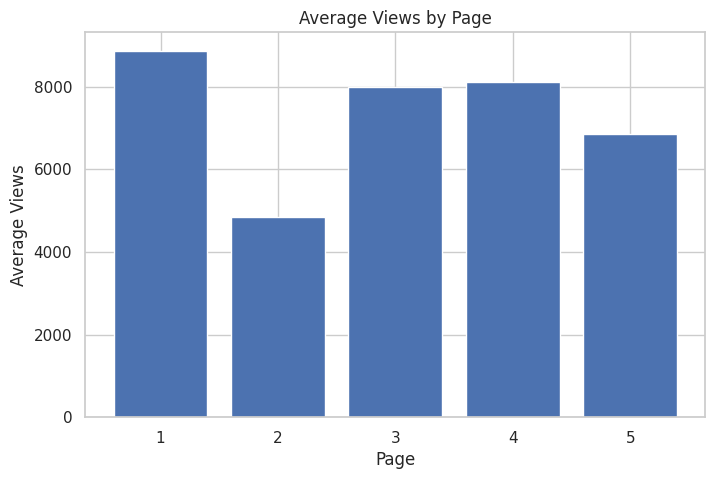

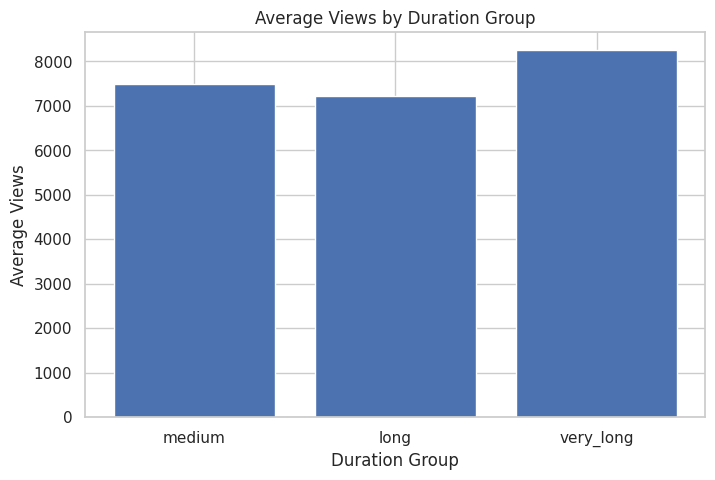

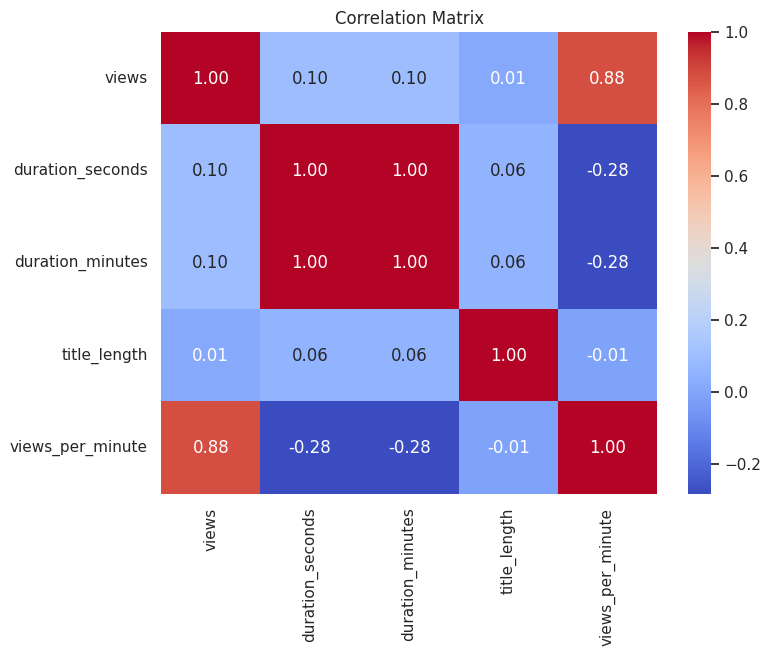


Average views by duration group:
duration_group
short                NaN
medium       7485.100000
long         7216.712121
very_long    8247.000000
Name: views, dtype: float64

Average views by page:
page
1    8876.50
2    4843.70
3    7997.45
4    8121.65
5    6852.90
Name: views, dtype: float64

Correlation between title length and views:
              title_length     views
title_length      1.000000  0.014579
views             0.014579  1.000000

Top 10 videos by views:
                                                                              title  views duration_raw  page
0       Кудрявая брюнетка скачет на члене и классно трясет голой задницей2395012:24  23950        12:24     1
14     Милфе с пышным телом по самые яйца засадили стояк в бритую пилотку2343412:25  23434        12:25     1
49   Киска с крашенными глазками умывается кончей после обильного камшота2309212:37  23092        12:37     3
71                30 летний холостяк резво жарит двух 18 летних студенток1967008

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("video_catalog_raw.csv")

def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    parts = str(x).split(":")
    try:
        parts = [int(p) for p in parts]
    except ValueError:
        return np.nan
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    elif len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    return np.nan

df["duration_seconds"] = df["duration_raw"].apply(duration_to_seconds)
df["duration_minutes"] = df["duration_seconds"] / 60
df["views"] = pd.to_numeric(df["views_raw"], errors="coerce")
df["title_length"] = df["title"].astype(str).str.len()
df["views_per_minute"] = df["views"] / df["duration_minutes"]
df["views_per_minute"] = df["views_per_minute"].replace([np.inf, -np.inf], np.nan)

df["duration_group"] = pd.cut(
    df["duration_seconds"],
    bins=[0, 300, 600, 900, 100000],
    labels=["short", "medium", "long", "very_long"]
)

print(df[["views", "duration_seconds", "duration_minutes", "title_length", "views_per_minute"]].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["views"].dropna(), bins=20)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["duration_minutes"].dropna(), bins=15)
plt.title("Distribution of Video Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["duration_minutes"], df["views"])
plt.title("Video Duration vs Views")
plt.xlabel("Duration (minutes)")
plt.ylabel("Views")
plt.show()

page_stats = df.groupby("page")["views"].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(page_stats["page"], page_stats["views"])
plt.title("Average Views by Page")
plt.xlabel("Page")
plt.ylabel("Average Views")
plt.show()

group_stats = df.groupby("duration_group", observed=False)["views"].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(group_stats["duration_group"].astype(str), group_stats["views"])
plt.title("Average Views by Duration Group")
plt.xlabel("Duration Group")
plt.ylabel("Average Views")
plt.show()

corr = df[["views", "duration_seconds", "duration_minutes", "title_length", "views_per_minute"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("\nAverage views by duration group:")
print(df.groupby("duration_group", observed=False)["views"].mean())

print("\nAverage views by page:")
print(df.groupby("page")["views"].mean())

print("\nCorrelation between title length and views:")
print(df[["title_length", "views"]].corr())

print("\nTop 10 videos by views:")
print(df.sort_values("views", ascending=False)[["title", "views", "duration_raw", "page"]].head(10))

Hypothesis 1

Shorter videos receive more views on average than longer videos.

The hypothesis is not strongly supported. Most videos have similar durations, and there is no clear evidence that shorter videos consistently receive more views.

Hypothesis 2

Videos on earlier pages have higher average views than those on later pages.

The hypothesis is supported. Videos on earlier pages show higher average views, indicating that ranking and visibility influence user engagement.

Hypothesis 3

There is a relationship between video duration and number of views.

The hypothesis is not supported. The analysis shows no strong correlation between video duration and views, suggesting that other factors determine popularity.